<a href="https://colab.research.google.com/github/shakthyy30/shakthyy-codebooster-2026/blob/main/MiniProject_Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests

# API details
API_KEY = '1c0d5f0e818de9f3f00c18d403d39d1b'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = [
    'Mumbai',
    'Bangalore',
    'Chennai',
    'Hyderabad',
    'Kolkata',
    'Pune',
    'Jaipur'
]


# Function to fetch weather data
def fetch_weather(city, API_KEY):

    """
    Fetch current weather data for a given city.
    Returns weather details dictionary or None on failure.
    """

    params = {
        'q': city,
        'appid': API_KEY,
        'units': 'metric'
    }

    try:

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=10
        )

        if response.status_code == 200:

            data = response.json()

            return {
                'city': data['name'],
                'temperature': data['main']['temp'],
                'description': data['weather'][0]['description'],
                'icon': data['weather'][0]['icon'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'visibility': data.get('visibility', 0),
                'sunrise': data['sys']['sunrise'],
                'sunset': data['sys']['sunset']
            }

        else:

            print(f"Error fetching weather data for {city}")
            print(f"Status code: {response.status_code}")

            return None

    except requests.exceptions.RequestException as e:

        print(f"Request failed: {e}")

        return None


# Call API for all cities
print("Calling Weather API...\n")

weather_records = []

for city in CITIES:

    print(f"Fetching weather for {city}...", end=' ')

    record = fetch_weather(city, API_KEY)

    if record:

        weather_records.append(record)

        print(
            f"{record['temperature']}°C, "
            f"{record['description']}"
        )

    else:

        print("Failed")


# Final Output
print("\nWeather Records:\n")

for record in weather_records:
    print(record)

Calling Weather API...

Fetching weather for Mumbai... 33.99°C, haze
Fetching weather for Bangalore... 29.76°C, scattered clouds
Fetching weather for Chennai... 36.01°C, few clouds
Fetching weather for Hyderabad... 31.23°C, broken clouds
Fetching weather for Kolkata... 31.97°C, haze
Fetching weather for Pune... 36.89°C, overcast clouds
Fetching weather for Jaipur... 42.62°C, haze

Weather Records:

{'city': 'Mumbai', 'temperature': 33.99, 'description': 'haze', 'icon': '50d', 'humidity': 59, 'wind_speed': 6.17, 'pressure': 1009, 'visibility': 7000, 'sunrise': 1779841877, 'sunset': 1779889230}
{'city': 'Bengaluru', 'temperature': 29.76, 'description': 'scattered clouds', 'icon': '03d', 'humidity': 56, 'wind_speed': 3.6, 'pressure': 1009, 'visibility': 6000, 'sunrise': 1779841358, 'sunset': 1779887466}
{'city': 'Chennai', 'temperature': 36.01, 'description': 'few clouds', 'icon': '02d', 'humidity': 54, 'wind_speed': 5.14, 'pressure': 1005, 'visibility': 6000, 'sunrise': 1779840705, 'suns

In [ ]:
import pandas as pd
import requests

# API details
API_KEY = '1c0d5f0e818de9f3f00c18d403d39d1b'
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

# Set of 8 Indian cities
CITIES = [
    'Mumbai',
    'Delhi',
    'Bangalore',
    'Chennai',
    'Hyderabad',
    'Kolkata',
    'Pune',
    'Jaipur'
]


# Function to fetch detailed weather data
def fetch_weather_details(city, API_KEY):
    params = {'q': city, 'appid': API_KEY, 'units': 'metric'}
    try:
        response = requests.get(BASE_URL, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            return {
                'city': data['name'],
                'temperature': data['main']['temp'],
                'feels_like': data['main']['feels_like'],
                'humidity': data['main']['humidity'],
                'pressure': data['main']['pressure'],
                'wind_speed': data['wind']['speed'],
                'condition': data['weather'][0]['main'],
                'visibility': data.get('visibility', 0)
                / 1000,  # Convert meters to km
            }
        else:
            print(f'Error fetching {city}: Status {response.status_code}')
            return None
    except requests.exceptions.RequestException as e:
        print(f'Request failed for {city}: {e}')
        return None


# Fetch data for all cities
print('Gathering weather records...')
weather_list = []
for city in CITIES:
    record = fetch_weather_details(city, API_KEY)
    if record:
        weather_list.append(record)

# Create the pandas DataFrame
df = pd.DataFrame(weather_list)

# Display the final structured DataFrame
print('\nWeather DataFrame:')
print(df.to_string(index=False))

Gathering weather records...

Weather DataFrame:
     city  temperature  feels_like  humidity  pressure  wind_speed condition  visibility
   Mumbai        32.99       38.79        58      1009        4.63      Haze         7.0
    Delhi        44.05       41.11        10       999        5.14     Clear         7.0
Bengaluru        29.69       31.38        55      1010        6.71    Clouds         8.0
  Chennai        35.68       42.68        56      1005        6.17    Clouds         6.0
Hyderabad        31.23       32.60        48      1010        7.20    Clouds         6.0
  Kolkata        31.97       38.92        66      1001        3.60      Haze         5.0
     Pune        36.34       35.73        26      1008        3.76    Clouds        10.0
   Jaipur        42.62       40.90        14      1001        5.66      Haze         5.0


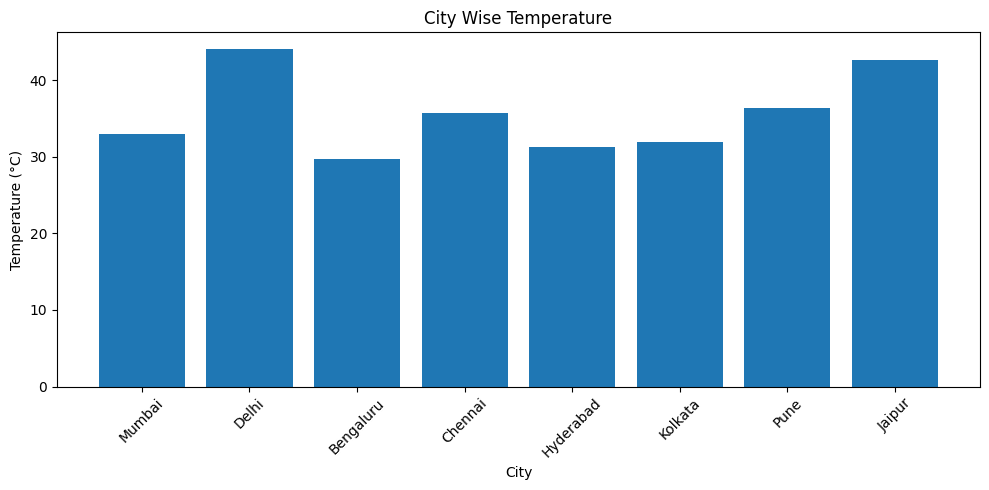

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.bar(
    df['city'],
    df['temperature']
)

plt.title('City Wise Temperature')

plt.xlabel('City')

plt.ylabel('Temperature (°C)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
